<a href="https://colab.research.google.com/github/LuanaMendonca/EDB1/blob/main/EDBtrabalho2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 02: Algoritmos de Ordenação

**Disciplina:** DIM0119 — Estruturas de Dados Básicas I  
**Aluna:** Luana Camily S. Mendonça  
**Professor:** Martin A. Musicante  

Este trabalho apresenta a implementação e a análise empírica de algoritmos de ordenação em C++. Os tempos de execução são medidos utilizando a biblioteca `chrono` e os resultados são analisados graficamente utilizando R.

## Algoritmos

O trabalho contém os seguintes algoritmos:

1. Insertion Sort  
2. Selection Sort  
3. Bubble Sort  
4. Quick Sort  
5. Merge Sort  
6. Comparação dos resultados

## Organização dos arquivos

```text
EDB_Trabalho2.ipynb     Notebook utilizado para executar os testes e gerar os gráficos

01.cpp                  Insertion Sort
02.cpp                  Selection Sort
03.cpp                  Bubble Sort
04.cpp                  Quick Sort
05.cpp                  Merge Sort

gerador_arquivos.cpp    Geração dos arquivos utilizados nos testes

p1v*.txt                Casos de pior caso da Questão 1
p2v*.txt                Casos de pior caso da Questão 2
...

resultadosquestao01.txt Resultados obtidos no Insertion Sort
```

## Compilação

Os programas podem ser compilados utilizando o compilador `g++`.

Exemplo para a Questão 1:

```bash
g++ 01.cpp -o 01
```

## Execução

Para executar normalmente:

```bash
./01
```

Para executar e salvar os resultados em um arquivo:

```bash
./01 > resultadosquestao01.txt
```

O mesmo procedimento pode ser utilizado para as demais questões, alterando o nome do arquivo correspondente.

Exemplo:

```bash
g++ 02.cpp -o 02
./02 > resultadosquestao02.txt
```

## Casos de teste

Os algoritmos são analisados considerando casos de melhor e pior desempenho.

Os arquivos de pior caso seguem a nomenclatura apresentados no documento t02.pdf disponibilizado dentro do sigaa:

```text
p<num>v<tam>.txt
```

onde:

- `num` representa o número da questão;
- `tam` representa o tamanho do vetor.

Exemplo:

```text
p1v10000.txt
```

representa um caso de teste da Questão 1 com 10.000 elementos.

Cada tamanho é executado várias vezes e o tempo médio é utilizado na análise.

## Gráficos

Os resultados gerados pelos programas em C++ são analisados utilizando R no Google Colab.

Nos gráficos:

- azul representa o melhor caso;
- vermelho representa o pior caso;
- círculo representa o melhor caso;
- triângulo representa o pior caso.

Os tempos são convertidos de nanossegundos para segundos para facilitar a leitura.

## Análise

Cada algoritmo possui uma análise individual de seu melhor e pior caso.

Ao final, os resultados dos cinco algoritmos são comparados na Questão 6, considerando os tempos obtidos nos testes e o comportamento observado conforme o tamanho dos vetores aumenta.

# **QUESTÃO 01 -  Insertion sort**

### **01 - Geração de casos de teste**


> Os arquivos abaixo representam casos de pior caso para o
Insertion Sort. Os vetores são armazenados em ordem decrescente.



In [ ]:
%%writefile gerador_arquivos.cpp

#include <iostream>
#include <fstream>
#include <string>

using namespace std;

int main() {

    int tamanhos[] = {0,100000,200000,300000,400000,500000};
    int quantidade = 6;

    for (int t = 0; t < quantidade; t++) {

        int tamanho = tamanhos[t];
        string nome = "p1v" + to_string(tamanho) + ".txt";
        ofstream arquivo(nome);

          for (int i = tamanho; i >= 1; i--) {
            arquivo << i << " ";
          }

        arquivo.close();
        cout << "Arquivo " << nome << " criado.\n";
    }

    return 0;
}

Compilar o código a cima

In [ ]:
!g++ gerador_arquivos.cpp -o gerador_arquivos

In [ ]:
!./gerador_arquivos

Arquivo p1v0.txt criado.
Arquivo p1v100000.txt criado.
Arquivo p1v200000.txt criado.
Arquivo p1v300000.txt criado.
Arquivo p1v400000.txt criado.
Arquivo p1v500000.txt criado.


### **02 - Implementação do Insertion Sort**



In [ ]:
%%writefile 01.cpp

#include <iostream>
#include <vector>
#include <chrono>
#include <fstream>
#include <string>
#include <algorithm>

using namespace std;

void insertionSort(vector<int>& v, int esq, int dir) {

    // percorre o vetor a partir do segundo elemento
    for (int i = esq + 1; i < dir; i++) {

        int atual = v[i];
        int j = i - 1;

        // move para a direita os elementos maiores que o atual
        while (j >= esq && v[j] > atual) {
            v[j + 1] = v[j];
            j--;
        }

        // coloca o elemento atual na posição correta
        v[j + 1] = atual;
    }
}

int main() {

    const int TRIALS = 5;

    int tamanhos[] = {0,100000,200000,300000,400000,500000};

    int quantidade = 6;

    // ---------------------------------------------------------
    // MELHOR CASO
    // ---------------------------------------------------------

    cout << "MELHORES CASOS - INSERTION SORT\n";
    cout << "Tamanho,Tempo_ns\n";

    for (int t = 0; t < quantidade; t++) {

        int tamanho = tamanhos[t];
        string nome = "p1v" + to_string(tamanho) + ".txt";
        ifstream arquivo(nome);

        if (!arquivo){
            cout << "Erro ao abrir " << nome << "\n";
            continue;
        }

        vector<int> original;

        int numero;

        while (arquivo >> numero){
            original.push_back(numero);
        }

        arquivo.close();

        // transforma o vetor em ordem crescente
        sort(original.begin(), original.end());

        long long totalDuration = 0;

        for (int teste = 0; teste < TRIALS; teste++){

            // cria uma cópia para cada execução
            vector<int> vec = original;

            auto start = chrono::high_resolution_clock::now();

            insertionSort(vec, 0, vec.size());

            auto end = chrono::high_resolution_clock::now();

            totalDuration += chrono::duration_cast<chrono::nanoseconds>(
                end - start
            ).count();
        }

        cout << tamanho << "," << totalDuration / TRIALS << "\n";
    }


    cout << "\n";


    // ---------------------------------------------------------
    // PIOR CASO
    // ---------------------------------------------------------

    cout << "PIORES CASOS - INSERTION SORT\n";
    cout << "Tamanho,Tempo_ns\n";

    for (int t = 0; t < quantidade; t++) {

        int tamanho = tamanhos[t];

        string nome = "p1v" + to_string(tamanho) + ".txt";

        ifstream arquivo(nome);

        if (!arquivo) {
            cout << "Erro ao abrir " << nome << "\n";
            continue;
        }

        vector<int> original;

        int numero;

        while (arquivo >> numero) {
            original.push_back(numero);
        }

        arquivo.close();

        long long totalDuration = 0;

        for (int teste = 0; teste < TRIALS; teste++) {

            // cria uma cópia para cada execução
            vector<int> vec = original;

            auto start = chrono::high_resolution_clock::now();

            insertionSort(vec, 0, vec.size());

            auto end = chrono::high_resolution_clock::now();

            totalDuration += chrono::duration_cast<chrono::nanoseconds>(
                end - start
            ).count();
        }

        cout << tamanho << "," << totalDuration / TRIALS << "\n";
    }

    return 0;
}

Overwriting 01.cpp


In [ ]:
!g++ 01.cpp -o 01

In [ ]:
!./01

MELHORES CASOS - INSERTION SORT
Tamanho,Tempo_ns
0,455
100000,1000669
200000,2099303
300000,3156973
400000,3860228
500000,4815791

PIORES CASOS - INSERTION SORT
Tamanho,Tempo_ns
0,53
100000,47916522794
200000,191062027483
300000,430851268641
400000,762663007794
^C


In [ ]:
%%writefile resultadosquestao01.txt

MELHORES CASOS - INSERTION SORT
Tamanho,Tempo_ns
0,455
100000,1000669
200000,2099303
300000,3156973
400000,3860228
500000,4815791

PIORES CASOS - INSERTION SORT
Tamanho,Tempo_ns
0,53
100000,47916522794
200000,191062027483
300000,430851268641
400000,762663007794

Writing resultadosquestao01.txt


In [ ]:
%%writefile questao01.csv

Tamanho,MelhorCaso_ns,PiorCaso_ns
0,455,53
100000,1000669,47916522794
200000,2099303,191062027483
300000,3156973,430851268641
400000,3860228,762663007794
500000,4815791,NA

Overwriting questao01.csv


### **03 - Gráficos**



In [ ]:
%load_ext rpy2.ipython

Primeiro vamos criar as tabelas de melhor e pior caso

In [ ]:
%%R

#ler arquivo
linhas <- readLines("resultadosquestao01.txt")

inicio_melhor <- which(linhas == "MELHORES CASOS - INSERTION SORT")
inicio_pior <- which(linhas == "PIORES CASOS - INSERTION SORT")

melhor_linhas <- linhas[(inicio_melhor + 2):(inicio_pior - 2)]
pior_linhas <- linhas[(inicio_pior + 2):length(linhas)]

#criar tabelas
melhor <- read.csv(text = paste(c("Tamanho,Tempo_ns", melhor_linhas), collapse = "\n"))
pior <- read.csv(text = paste(c("Tamanho,Tempo_ns", pior_linhas), collapse = "\n"))

#converter para segundos
melhor$Tempo_s <- melhor$Tempo_ns / 1000000000
pior$Tempo_s <- pior$Tempo_ns / 1000000000

#mostrar tabelas
cat("MELHOR CASO - INSERTION SORT\n")
print(melhor[, c("Tamanho", "Tempo_s")])

cat("\nPIOR CASO - INSERTION SORT\n")
print(pior[, c("Tamanho", "Tempo_s")])

MELHOR CASO - INSERTION SORT
  Tamanho     Tempo_s
1       0 0.000000455
2  100000 0.001000669
3  200000 0.002099303
4  300000 0.003156973
5  400000 0.003860228
6  500000 0.004815791

PIOR CASO - INSERTION SORT
  Tamanho      Tempo_s
1       0 5.300000e-08
2  100000 4.791652e+01
3  200000 1.910620e+02
4  300000 4.308513e+02
5  400000 7.626630e+02


Agora vamos criar o gráfico

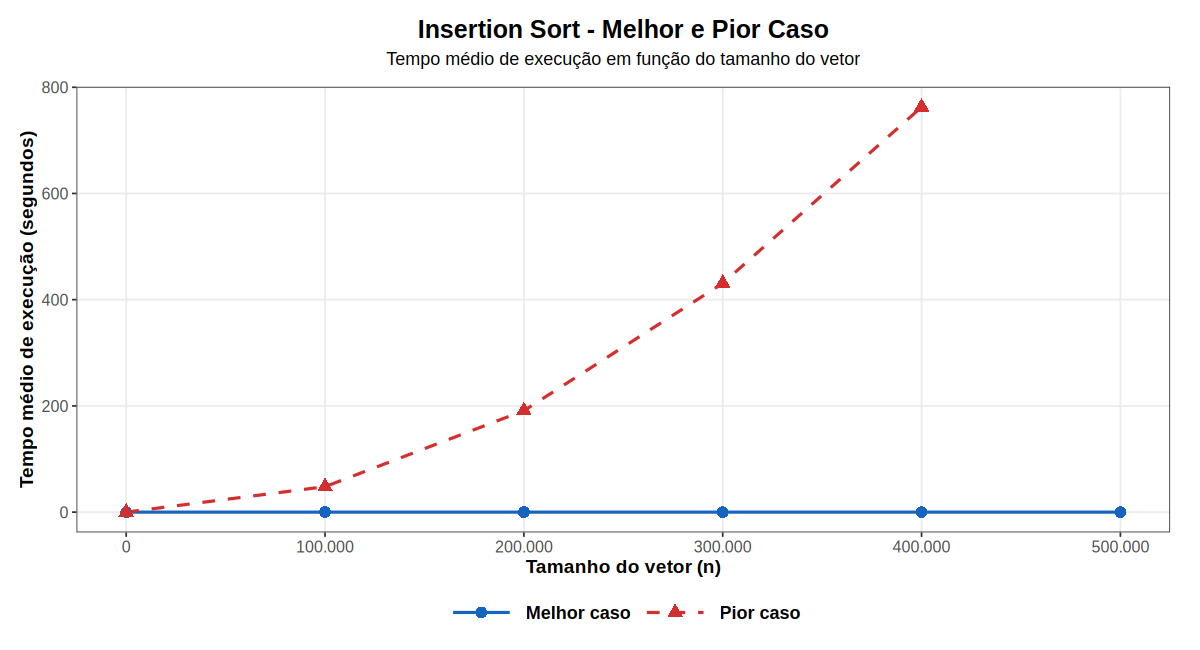

In [ ]:
%%R -w 1200 -h 650

library(ggplot2)

#identificar casos
melhor$Caso <- "Melhor caso"
pior$Caso <- "Pior caso"

#juntar dados
dados <- rbind(
  melhor[, c("Tamanho", "Tempo_s", "Caso")],
  pior[, c("Tamanho", "Tempo_s", "Caso")]
)

#criar grafico
grafico <- ggplot(dados, aes(x = Tamanho, y = Tempo_s, color = Caso, shape = Caso, linetype = Caso)) +
  geom_line(linewidth = 1.5) +
  geom_point(size = 5) +

  scale_color_manual(values = c("Melhor caso" = "#1565C0", "Pior caso" = "#D32F2F")) +
  scale_shape_manual(values = c("Melhor caso" = 16, "Pior caso" = 17)) +
  scale_linetype_manual(values = c("Melhor caso" = "solid", "Pior caso" = "dashed")) +

  scale_x_continuous(
    breaks = seq(0, max(dados$Tamanho), by = 100000),
    labels = function(x) format(
      x,
      big.mark = ".",
      decimal.mark = ",",
      scientific = FALSE,
      trim = TRUE
    )
  ) +

  labs(
    title = "Insertion Sort - Melhor e Pior Caso",
    subtitle = "Tempo médio de execução em função do tamanho do vetor",
    x = "Tamanho do vetor (n)",
    y = "Tempo médio de execução (segundos)",
    color = NULL,
    shape = NULL,
    linetype = NULL
  ) +

  theme_bw(base_size = 18) +

  theme(
    plot.title = element_text(size = 25, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 18, hjust = 0.5, margin = margin(b = 18)),
    axis.title = element_text(size = 19, face = "bold"),
    axis.text = element_text(size = 16),
    legend.position = "bottom",
    legend.text = element_text(size = 18, face = "bold"),
    legend.key.width = unit(2.5, "cm"),
    panel.grid.minor = element_blank(),
    plot.margin = margin(20, 30, 20, 20)
  )

#mostrar grafico
print(grafico)

#salvar grafico
ggsave("questao01_grafico.png", plot = grafico, width = 12, height = 6, units = "in", dpi = 300)

IMAGEM DO GRÁFICO


> Pior caso triângulos em vermelho e Melhor caso bolinhas em azul



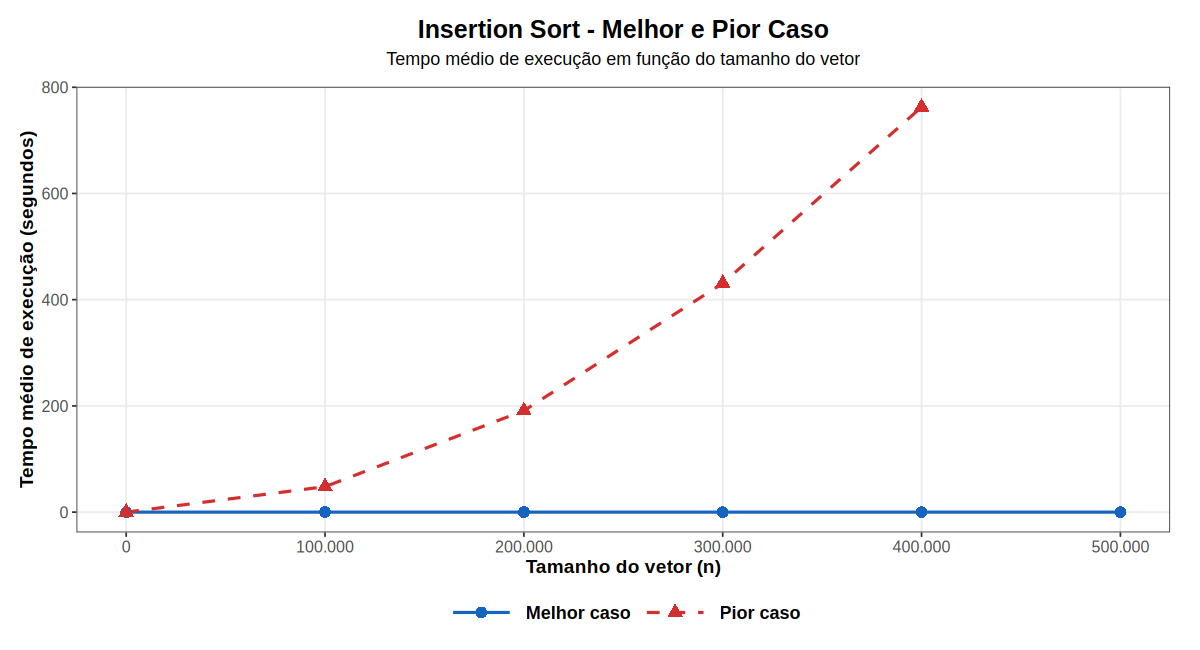

## **04 - Relatório**

**Conclusão**

Os testes mostraram que o Insertion Sort apresenta melhor desempenho quando o vetor já está ordenado, apresentando comportamento próximo de `O(n)`. No pior caso, com o vetor em ordem decrescente, o tempo de execução cresce de forma mais acentuada, seguindo `O(n²)`. Dessa forma, o algoritmo apresenta bom desempenho para vetores menores ou já ordenados, mas perde eficiência à medida que o tamanho da entrada aumenta.

Durante os testes do pior caso, a execução com 500.000 elementos não foi concluída devido ao elevado tempo de processamento. Por esse motivo, os resultados considerados na análise foram obtidos até 400.000 elementos, mantendo cinco execuções para cada tamanho concluído e utilizando o tempo médio dessas execuções.

# **QUESTÃO 02: Selection sort**

## **01 - Casos de teste**

In [ ]:
%%writefile casos02.cpp

#include <iostream>
#include <vector>

using namespace std;

int main() {

    int tamanhos[] = {0, 100000, 200000, 300000, 400000, 500000};

    for (int t = 0; t < 6; t++) {

        int tamanho = tamanhos[t];

        vector<int> melhor(tamanho);
        vector<int> pior(tamanho);

        //melhor caso
        for (int i = 0; i < tamanho; i++) {
            melhor[i] = i;
        }

        //pior caso
        for (int i = 0; i < tamanho; i++) {
            pior[i] = tamanho - 1 - i;
        }

        cout << "Tamanho: " << tamanho << endl;

        cout << "Melhor caso: ";
        for (int i = 0; i < tamanho && i < 10; i++) {
            cout << melhor[i] << " ";
        }

        cout << endl;

        cout << "Pior caso: ";
        for (int i = 0; i < tamanho && i < 10; i++) {
            cout << pior[i] << " ";
        }

        cout << endl << endl;
    }

    return 0;
}

Writing casos02.cpp


In [ ]:
!g++ casos02.cpp -o casos02

In [ ]:
!./casos02

Tamanho: 0
Melhor caso: 
Pior caso: 

Tamanho: 100000
Melhor caso: 0 1 2 3 4 5 6 7 8 9 
Pior caso: 99999 99998 99997 99996 99995 99994 99993 99992 99991 99990 

Tamanho: 200000
Melhor caso: 0 1 2 3 4 5 6 7 8 9 
Pior caso: 199999 199998 199997 199996 199995 199994 199993 199992 199991 199990 

Tamanho: 300000
Melhor caso: 0 1 2 3 4 5 6 7 8 9 
Pior caso: 299999 299998 299997 299996 299995 299994 299993 299992 299991 299990 

Tamanho: 400000
Melhor caso: 0 1 2 3 4 5 6 7 8 9 
Pior caso: 399999 399998 399997 399996 399995 399994 399993 399992 399991 399990 

Tamanho: 500000
Melhor caso: 0 1 2 3 4 5 6 7 8 9 
Pior caso: 499999 499998 499997 499996 499995 499994 499993 499992 499991 499990 



## **02 - Implementação**

In [ ]:
%%writefile 02.cpp

#include <iostream>
#include <vector>
#include <chrono>

using namespace std;

void selectionSort(vector<int> &v, int esq, int dir) {
    for (int i = esq; i < dir - 1; i++) {
        int menor = i;

        for (int j = i + 1; j < dir; j++) {
            if (v[j] < v[menor]) {
                menor = j;
            }
        }

        int aux = v[i];
        v[i] = v[menor];
        v[menor] = aux;
    }
}

int main() {
    const int INICIO = 0;
    const int FIM = 500000;
    const int PASSO = 100000;
    const int TESTES = 5;

    cout << "Tamanho,MelhorCaso_ns,PiorCaso_ns" << endl;

    for (int tamanho = INICIO; tamanho <= FIM; tamanho += PASSO) {
        long long totalMelhor = 0;
        long long totalPior = 0;

        for (int t = 0; t < TESTES; t++) {
            vector<int> melhor(tamanho);

            for (int i = 0; i < tamanho; i++) {
                melhor[i] = i;
            }

            auto inicio = chrono::high_resolution_clock::now();

            selectionSort(melhor, 0, tamanho);

            auto fim = chrono::high_resolution_clock::now();

            totalMelhor += chrono::duration_cast<chrono::nanoseconds>(fim - inicio).count();

            vector<int> pior(tamanho);

            for (int i = 0; i < tamanho; i++) {
                pior[i] = tamanho - i;
            }

            inicio = chrono::high_resolution_clock::now();

            selectionSort(pior, 0, tamanho);

            fim = chrono::high_resolution_clock::now();

            totalPior += chrono::duration_cast<chrono::nanoseconds>(fim - inicio).count();
        }

        cout << tamanho << ","
             << totalMelhor / TESTES << ","
             << totalPior / TESTES << endl;
    }

    return 0;
}

Overwriting 02.cpp


In [ ]:
!g++ 02.cpp -o 02

In [ ]:
!./02

Tamanho: 0
Melhor caso: 0.000000 segundos
Pior caso: 0.000000 segundos

Tamanho: 100000
^C


Salva os dados gerados em um arquivo

In [ ]:
%%writefile questao02.csv
Tamanho,MelhorCaso_ns,PiorCaso_ns
0,62,34
100000,34055810888,32506808707
200000,132130144480,129806411800
300000,296125229805,290348342526
400000,542735965022,537916254167

Writing questao02.csv


Visualização do arquivo gerado

In [ ]:
!cat questao02.csv

Tamanho,MelhorCaso_ns,PiorCaso_ns
0,62,34
100000,34055810888,32506808707
200000,132130144480,129806411800
300000,296125229805,290348342526
400000,542735965022,537916254167


## **03 - Gráficos**

Geração de tabela para visualizar se os dados do arquivo foram salvos corretamente

In [ ]:
%%R

dados <- read.csv("questao02.csv")

melhor <- data.frame(
  Tamanho = dados$Tamanho,
  Tempo_s = dados$MelhorCaso_ns / 1000000000
)

pior <- data.frame(
  Tamanho = dados$Tamanho,
  Tempo_s = dados$PiorCaso_ns / 1000000000
)
cat("MELHOR CASO - INSERTION SORT\n")
print(melhor)
cat("PIOR CASO - INSERTION SORT\n")
print(pior)

MELHOR CASO - INSERTION SORT
  Tamanho      Tempo_s
1       0 6.200000e-08
2  100000 3.405581e+01
3  200000 1.321301e+02
4  300000 2.961252e+02
5  400000 5.427360e+02
PIOR CASO - INSERTION SORT
  Tamanho      Tempo_s
1       0 3.400000e-08
2  100000 3.250681e+01
3  200000 1.298064e+02
4  300000 2.903483e+02
5  400000 5.379163e+02


Geração de grafico

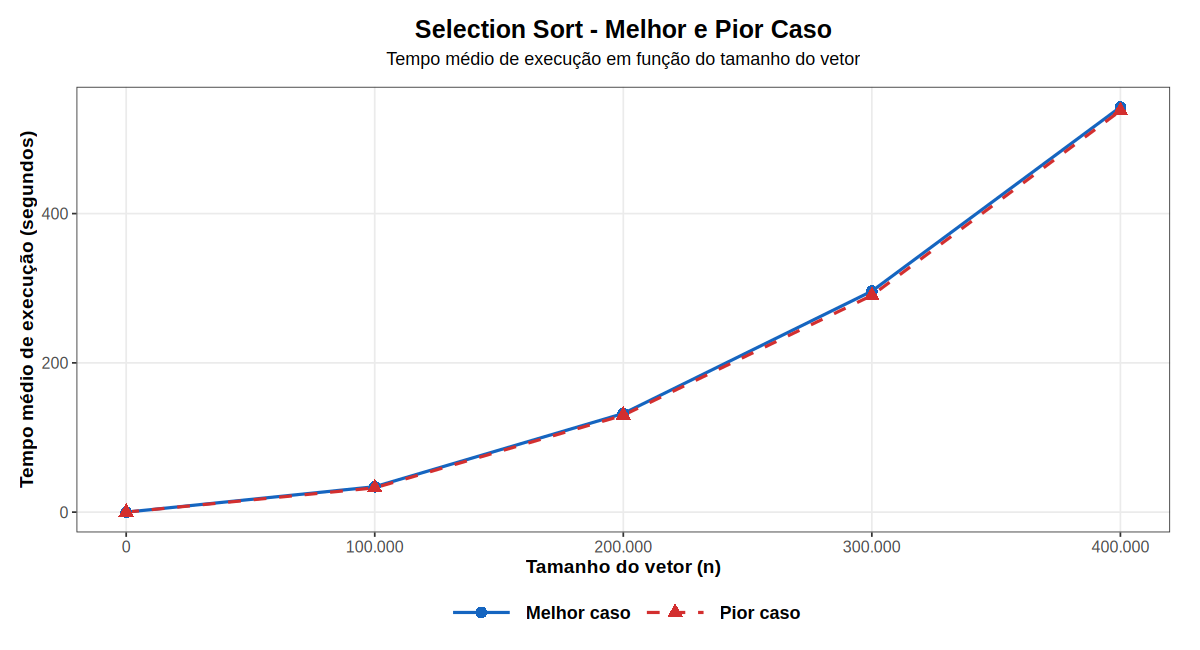

In [ ]:
%%R -w 1200 -h 650

library(ggplot2)

#identificar casos
melhor$Caso <- "Melhor caso"
pior$Caso <- "Pior caso"

#juntar dados
dados_grafico <- rbind(
  melhor[, c("Tamanho", "Tempo_s", "Caso")],
  pior[, c("Tamanho", "Tempo_s", "Caso")]
)

#criar grafico
grafico <- ggplot(dados_grafico, aes(x = Tamanho, y = Tempo_s, color = Caso, shape = Caso, linetype = Caso)) +
  geom_line(linewidth = 1.5) +
  geom_point(size = 5) +

  scale_color_manual(values = c("Melhor caso" = "#1565C0", "Pior caso" = "#D32F2F")) +
  scale_shape_manual(values = c("Melhor caso" = 16, "Pior caso" = 17)) +
  scale_linetype_manual(values = c("Melhor caso" = "solid", "Pior caso" = "dashed")) +

  scale_x_continuous(
    breaks = seq(0, max(dados_grafico$Tamanho), by = 100000),
    labels = function(x) format(
      x,
      big.mark = ".",
      decimal.mark = ",",
      scientific = FALSE,
      trim = TRUE
    )
  ) +

  labs(
    title = "Selection Sort - Melhor e Pior Caso",
    subtitle = "Tempo médio de execução em função do tamanho do vetor",
    x = "Tamanho do vetor (n)",
    y = "Tempo médio de execução (segundos)",
    color = NULL,
    shape = NULL,
    linetype = NULL
  ) +

  theme_bw(base_size = 18) +

  theme(
    plot.title = element_text(size = 25, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 18, hjust = 0.5, margin = margin(b = 18)),
    axis.title = element_text(size = 19, face = "bold"),
    axis.text = element_text(size = 16),
    legend.position = "bottom",
    legend.text = element_text(size = 18, face = "bold"),
    legend.key.width = unit(2.5, "cm"),
    panel.grid.minor = element_blank(),
    plot.margin = margin(20, 30, 20, 20)
  )

#mostrar grafico
print(grafico)

#salvar grafico
ggsave("questao02_grafico.png", plot = grafico, width = 12, height = 6, units = "in", dpi = 300)

GRAFICO SELECTION SORT

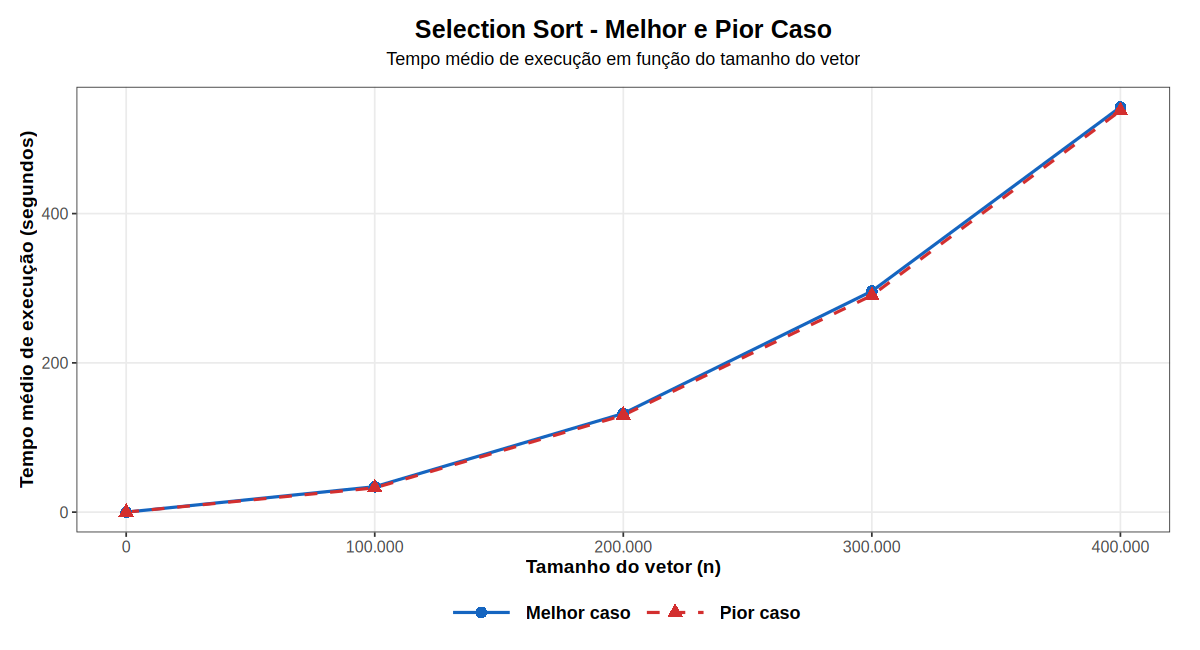

## **04 - Relatório**

Os testes mostraram que o Selection Sort apresenta tempos de execução semelhantes no melhor e no pior caso. Isso acontece porque o algoritmo continua percorrendo o restante do vetor para encontrar o menor elemento, mesmo quando os dados já estão ordenados. Por esse motivo, seu comportamento permanece próximo de `O(n²)` nos dois casos.

Nos resultados obtidos, o tempo de execução aumentou bastante conforme o tamanho do vetor cresceu. A execução com 500.000 elementos não foi concluída devido ao elevado tempo de processamento, então a análise foi feita com os resultados obtidos até 400.000 elementos. Para cadaa tamanho concluído, foram realizadas cinco execuções e utilizado o tempo médio.

# **QUESTÃO 03 - Bubble sort**

## **01 - Casos de testes**

In [ ]:
%%writefile arquivos_testes_03.cpp

#include <iostream>
#include <fstream>
#include <string>

using namespace std;

int main() {

    int tamanhos[] = {0, 100000, 200000, 300000, 400000};

    for (int i = 0; i < 5; i++) {

        int tamanho = tamanhos[i];

        string nome = "p3v" + to_string(tamanho) + ".txt";

        ofstream arquivo(nome);

        //pior caso
        for (int j = tamanho; j > 0; j--) {
            arquivo << j << " ";
        }

        arquivo.close();

        cout << nome << " criado" << endl;
    }

    return 0;
}

Overwriting arquivos_testes_03.cpp


In [ ]:
!g++ arquivos_testes_03.cpp -o arquivos_testes_03

In [ ]:
!./arquivos_testes_03

p3v0.txt criado
p3v100000.txt criado
p3v200000.txt criado
p3v300000.txt criado
p3v400000.txt criado


## **02 - Implementação**

In [ ]:
%%writefile 03.cpp

#include <iostream>
#include <vector>
#include <chrono>
#include <fstream>
#include <string>

using namespace std;

//bubble sort
void bubbleSort(vector<int> &v, int esq, int dir) {

    bool trocou = true;
    int fim = dir - 1;

    while (trocou) {

        trocou = false;

        for (int i = esq; i < fim; i++) {

            if (v[i] > v[i + 1]) {

                int aux = v[i];
                v[i] = v[i + 1];
                v[i + 1] = aux;

                trocou = true;
            }
        }

        fim--;
    }
}

int main() {

    int tamanhos[] = {0, 100000, 200000, 300000, 400000};
    int testes = 5;

    cout << "Tamanho,MelhorCaso_ns,PiorCaso_ns" << endl;

    for (int i = 0; i < 5; i++) {

        int tamanho = tamanhos[i];

        //melhor caso
        vector<int> melhor(tamanho);

        for (int j = 0; j < tamanho; j++) {
            melhor[j] = j;
        }

        //pior caso
        vector<int> pior(tamanho);

        string nome = "p3v" + to_string(tamanho) + ".txt";
        ifstream arquivo(nome);

        for (int j = 0; j < tamanho; j++) {
            arquivo >> pior[j];
        }

        arquivo.close();

        long long tempoMelhor = 0;
        long long tempoPior = 0;

        //executar testes
        for (int j = 0; j < testes; j++) {

            vector<int> copiaMelhor = melhor;

            auto inicio = chrono::high_resolution_clock::now();

            bubbleSort(copiaMelhor, 0, copiaMelhor.size());

            auto fim = chrono::high_resolution_clock::now();

            tempoMelhor += chrono::duration_cast<chrono::nanoseconds>(fim - inicio).count();


            vector<int> copiaPior = pior;

            inicio = chrono::high_resolution_clock::now();

            bubbleSort(copiaPior, 0, copiaPior.size());

            fim = chrono::high_resolution_clock::now();

            tempoPior += chrono::duration_cast<chrono::nanoseconds>(fim - inicio).count();
        }

        //calcular media
        tempoMelhor = tempoMelhor / testes;
        tempoPior = tempoPior / testes;

        //salvar resultados
        cout << tamanho << "," << tempoMelhor << "," << tempoPior << endl;
    }

    return 0;
}

Writing 03.cpp


In [ ]:
!g++ 03.cpp -o 03

In [ ]:
!./03

Tamanho,MelhorCaso_ns,PiorCaso_ns
0,168,47
100000,702608,90707153538
200000,1486794,364111505958
300000,2023867,819990309222
^C


Para salvar os dados em um arquivo para serem lidos pelo R

In [ ]:
%%writefile questao03.csv
Tamanho,MelhorCaso_ns,PiorCaso_ns
0,168,47
100000,702608,90707153538
200000,1486794,364111505958
300000,2023867,819990309222

Writing questao03.csv


## **03 - Gráficos**

Para ler o arquivo e mostrar a tabela

Para ativar o R em python

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R

dados <- read.csv("questao03.csv")

melhor <- data.frame(
  Tamanho = dados$Tamanho,
  Tempo_s = dados$MelhorCaso_ns / 1000000000
)

pior <- data.frame(
  Tamanho = dados$Tamanho,
  Tempo_s = dados$PiorCaso_ns / 1000000000
)

cat("MELHOR CASO - BUBBLE SORT\n")
print(melhor)

cat("PIOR CASO - BUBBLE SORT\n")
print(pior)

MELHOR CASO - BUBBLE SORT
  Tamanho     Tempo_s
1       0 0.000000168
2  100000 0.000702608
3  200000 0.001486794
4  300000 0.002023867
PIOR CASO - BUBBLE SORT
  Tamanho      Tempo_s
1       0 4.700000e-08
2  100000 9.070715e+01
3  200000 3.641115e+02
4  300000 8.199903e+02


Para gerar o gráfico

Need help? Try Stackoverflow: https://stackoverflow.com/tags/ggplot2


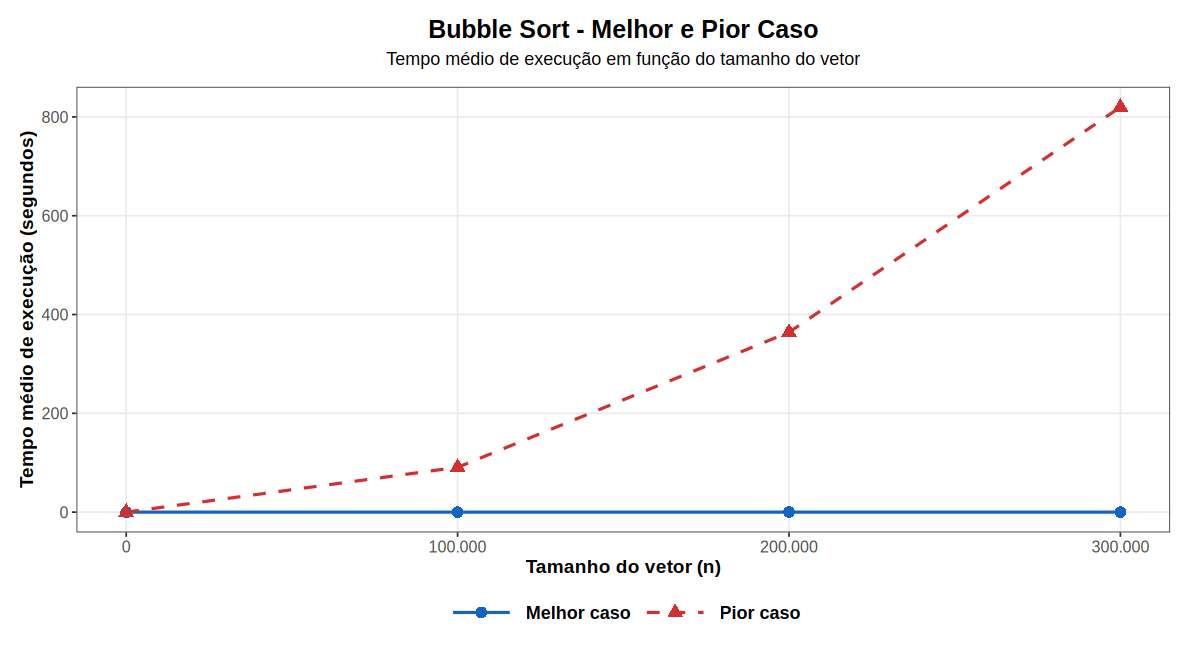

In [ ]:
%%R -w 1200 -h 650

library(ggplot2)

#identificar casos
melhor$Caso <- "Melhor caso"
pior$Caso <- "Pior caso"

#juntar dados
dados_grafico <- rbind(
  melhor[, c("Tamanho", "Tempo_s", "Caso")],
  pior[, c("Tamanho", "Tempo_s", "Caso")]
)

#criar grafico
grafico <- ggplot(dados_grafico, aes(x = Tamanho, y = Tempo_s, color = Caso, shape = Caso, linetype = Caso)) +
  geom_line(linewidth = 1.5) +
  geom_point(size = 5) +
  scale_color_manual(values = c("Melhor caso" = "#1565C0", "Pior caso" = "#D32F2F")) +
  scale_shape_manual(values = c("Melhor caso" = 16, "Pior caso" = 17)) +
  scale_linetype_manual(values = c("Melhor caso" = "solid", "Pior caso" = "dashed")) +
  scale_x_continuous(
    breaks = seq(0, max(dados_grafico$Tamanho), by = 100000),
    labels = function(x) format(
      x,
      big.mark = ".",
      decimal.mark = ",",
      scientific = FALSE,
      trim = TRUE
    )
  ) +
  labs(
    title = "Bubble Sort - Melhor e Pior Caso",
    subtitle = "Tempo médio de execução em função do tamanho do vetor",
    x = "Tamanho do vetor (n)",
    y = "Tempo médio de execução (segundos)",
    color = NULL,
    shape = NULL,
    linetype = NULL
  ) +
  theme_bw(base_size = 18) +
  theme(
    plot.title = element_text(size = 25, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 18, hjust = 0.5, margin = margin(b = 18)),
    axis.title = element_text(size = 19, face = "bold"),
    axis.text = element_text(size = 16),
    legend.position = "bottom",
    legend.text = element_text(size = 18, face = "bold"),
    legend.key.width = unit(2.5, "cm"),
    panel.grid.minor = element_blank(),
    plot.margin = margin(20, 30, 20, 20)
  )

#mostrar grafico
print(grafico)

#salvar grafico
ggsave("questao03_grafico.png", plot = grafico, width = 12, height = 6, units = "in", dpi = 300)

GRÁFICO MELHOR E PIOR CASO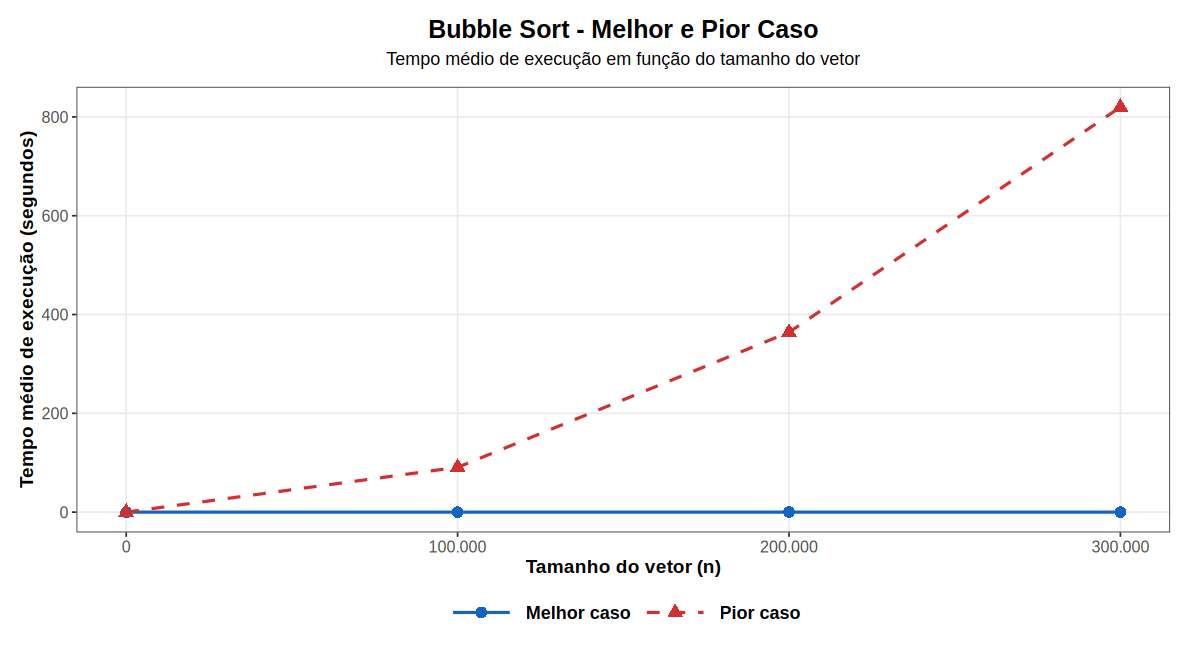

## **04 - Relatório**

Os testes mostraram uma grande diferença entre o melhor e o pior caso do Bubble Sort. No melhor caso, com o vetor já ordenado, o algoritmo apresentou tempos muito baixos, pois encerra a execução quando não são realizadas trocas. Já no pior caso, com o vetor em ordem decrescente, o tempo aumentou rapidamente conforme o tamanho do vetor, comportamento esperado para um algoritmo de complexidade O(n²).

Durante os testes com entradas maiores, o Google Colab chegou a encerrar o ambiente de execução devido ao longo tempo de processamento. Foi necessário reiniciar o ambiente para continuar alguns testes. Por esse motivo, essa limitação do ambiente foi considerada durante a análise dos resultados.

**Imagem que comprova o erro dentro do ambiente do colab**
Por isso os meus experimentos ficaram limitados em 400.000
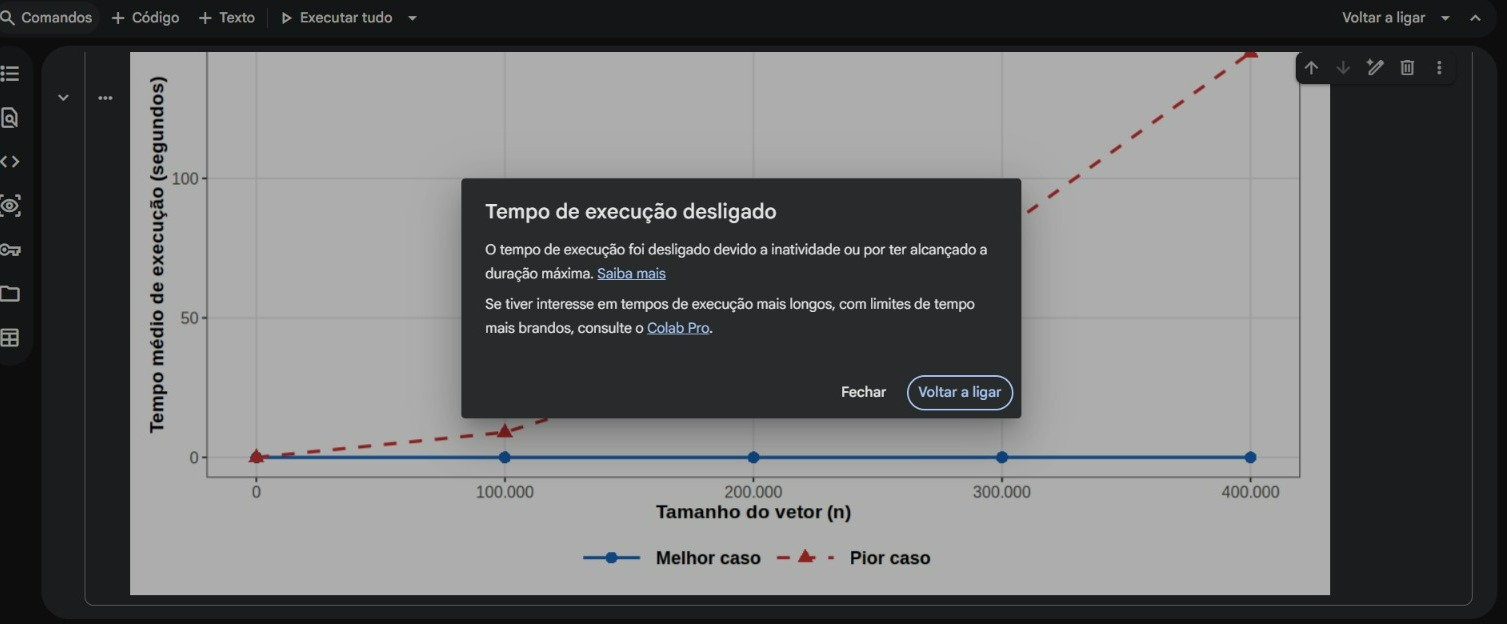

# **QUESTÃO 04 -  Quick sort**

## **01 - Casos de testes**

In [ ]:
%%writefile gerador_q4.cpp

#include <iostream>
#include <fstream>
#include <string>

using namespace std;

int main() {

    int tamanhos[] = {0, 100000, 200000, 300000, 400000};

    for (int i = 0; i < 5; i++) {

        int tamanho = tamanhos[i];
        string nome = "p4v" + to_string(tamanho) + ".txt";

        ofstream arquivo(nome);

        //pior caso
        for (int j = tamanho; j > 0; j--) {
            arquivo << j << " ";
        }

        arquivo.close();

        cout << nome << " criado" << endl;
    }

    return 0;
}

In [ ]:
!g++ gerador_q4.cpp -o gerador_q4

In [ ]:
!./gerador_q4

## **02 - Implementação**

In [ ]:
%%writefile 04.cpp

#include <iostream>
#include <vector>
#include <fstream>
#include <chrono>
#include <string>

using namespace std;

//faz a particao usando o ultimo elemento como pivo
int particiona(vector<int> &v, int esq, int dir) {
    int pivo = v[dir - 1];
    int i = esq;

    for (int j = esq; j < dir - 1; j++) {
        if (v[j] <= pivo) {
            swap(v[i], v[j]);
            i++;
        }
    }

    swap(v[i], v[dir - 1]);

    return i;
}

//ordena o intervalo [esq, dir)
void quickSort(vector<int> &v, int esq, int dir) {
    if (dir - esq <= 1) {
        return;
    }

    int pivo = particiona(v, esq, dir);

    quickSort(v, esq, pivo);
    quickSort(v, pivo + 1, dir);
}

//gera um caso em que as particoes ficam mais equilibradas
void gerarMelhorCaso(vector<int> &v, int inicio, int fim) {
    if (inicio > fim) {
        return;
    }

    int meio = (inicio + fim) / 2;

    gerarMelhorCaso(v, inicio, meio - 1);

    int inicioDireita = v.size();

    gerarMelhorCaso(v, meio + 1, fim);

    if (v.size() > inicioDireita) {
        int ultimo = v[v.size() - 1];

        for (int i = v.size() - 1; i > inicioDireita; i--) {
            v[i] = v[i - 1];
        }

        v[inicioDireita] = ultimo;
    }

    v.push_back(meio);
}

//le os valores do arquivo do pior caso
vector<int> lerArquivo(string nome) {
    vector<int> v;
    ifstream arquivo(nome);
    int valor;

    while (arquivo >> valor) {
        v.push_back(valor);
    }

    arquivo.close();

    return v;
}

int main() {

    int tamanhos[] = {0, 100000, 200000, 300000, 400000};
    int testes = 5;

    cout << "MELHORES CASOS - QUICK SORT" << endl;
    cout << "Tamanho,Tempo_ns" << endl;

    for (int t = 0; t < 5; t++) {

        int tamanho = tamanhos[t];

        vector<int> original;
        original.reserve(tamanho);

        gerarMelhorCaso(original, 1, tamanho);

        long long total = 0;

        for (int teste = 0; teste < testes; teste++) {

            vector<int> v = original;

            auto inicio = chrono::high_resolution_clock::now();

            quickSort(v, 0, v.size());

            auto fim = chrono::high_resolution_clock::now();

            total += chrono::duration_cast<chrono::nanoseconds>(fim - inicio).count();
        }

        cout << tamanho << "," << total / testes << endl;
    }

    cout << endl;

    cout << "PIORES CASOS - QUICK SORT" << endl;
    cout << "Tamanho,Tempo_ns" << endl;

    for (int t = 0; t < 5; t++) {

        int tamanho = tamanhos[t];

        string nome = "p4v" + to_string(tamanho) + ".txt";

        vector<int> original = lerArquivo(nome);

        long long total = 0;

        for (int teste = 0; teste < testes; teste++) {

            vector<int> v = original;

            auto inicio = chrono::high_resolution_clock::now();

            quickSort(v, 0, v.size());

            auto fim = chrono::high_resolution_clock::now();

            total += chrono::duration_cast<chrono::nanoseconds>(fim - inicio).count();
        }

        cout << tamanho << "," << total / testes << endl;
    }

    return 0;
}

In [ ]:
!g++ -O2 04.cpp -o 04

In [ ]:
!./04

MELHORES CASOS - QUICK SORT
Tamanho,Tempo_ns
0,53
100000,3044019
200000,5669088
300000,9392105
400000,11688344

PIORES CASOS - QUICK SORT
Tamanho,Tempo_ns
0,36
100000,8978816479
200000,36580534247
300000,81266426468
400000,145082383520


Salvando os dados formatados para a criação do grafico em R

In [30]:
%%writefile questao04.csv
Tamanho,MelhorCaso_ns,PiorCaso_ns
0,53,36
100000,3044019,8978816479
200000,5669088,36580534247
300000,9392105,81266426468
400000,11688344,145082383520

Writing questao04.csv


## **03 - Gráficos**

Para gerar a tabela com os gáficos

In [ ]:
%%R

dados <- read.csv("questao04.csv")

melhor <- data.frame(
  Tamanho = dados$Tamanho,
  Tempo_s = dados$MelhorCaso_ns / 1000000000
)

pior <- data.frame(
  Tamanho = dados$Tamanho,
  Tempo_s = dados$PiorCaso_ns / 1000000000
)

cat("MELHOR CASO - QUICK SORT\n")
print(melhor)

cat("PIOR CASO - QUICK SORT\n")
print(pior)

Para gerar os gráficos

In [ ]:
%%R -w 1200 -h 650

library(ggplot2)

#identificar casos
melhor$Caso <- "Melhor caso"
pior$Caso <- "Pior caso"

#juntar dados
dados_grafico <- rbind(
  melhor[, c("Tamanho", "Tempo_s", "Caso")],
  pior[, c("Tamanho", "Tempo_s", "Caso")]
)

#criar grafico
grafico <- ggplot(dados_grafico, aes(x = Tamanho, y = Tempo_s, color = Caso, shape = Caso, linetype = Caso)) +
  geom_line(linewidth = 1.5) +
  geom_point(size = 5) +

  scale_color_manual(values = c("Melhor caso" = "#1565C0", "Pior caso" = "#D32F2F")) +
  scale_shape_manual(values = c("Melhor caso" = 16, "Pior caso" = 17)) +
  scale_linetype_manual(values = c("Melhor caso" = "solid", "Pior caso" = "dashed")) +

  scale_x_continuous(
    breaks = seq(0, max(dados_grafico$Tamanho), by = 100000),
    labels = function(x) format(
      x,
      big.mark = ".",
      decimal.mark = ",",
      scientific = FALSE,
      trim = TRUE
    )
  ) +

  labs(
    title = "Quick Sort - Melhor e Pior Caso",
    subtitle = "Tempo médio de execução em função do tamanho do vetor",
    x = "Tamanho do vetor (n)",
    y = "Tempo médio de execução (segundos)",
    color = NULL,
    shape = NULL,
    linetype = NULL
  ) +

  theme_bw(base_size = 18) +

  theme(
    plot.title = element_text(size = 25, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 18, hjust = 0.5, margin = margin(b = 18)),
    axis.title = element_text(size = 19, face = "bold"),
    axis.text = element_text(size = 16),
    legend.position = "bottom",
    legend.text = element_text(size = 18, face = "bold"),
    legend.key.width = unit(2.5, "cm"),
    panel.grid.minor = element_blank(),
    plot.margin = margin(20, 30, 20, 20)
  )

#mostrar grafico
print(grafico)

#salvar grafico
ggsave("questao04_grafico.png", plot = grafico, width = 12, height = 6, units = "in", dpi = 300)

IMAGEM DO GRÁFICO

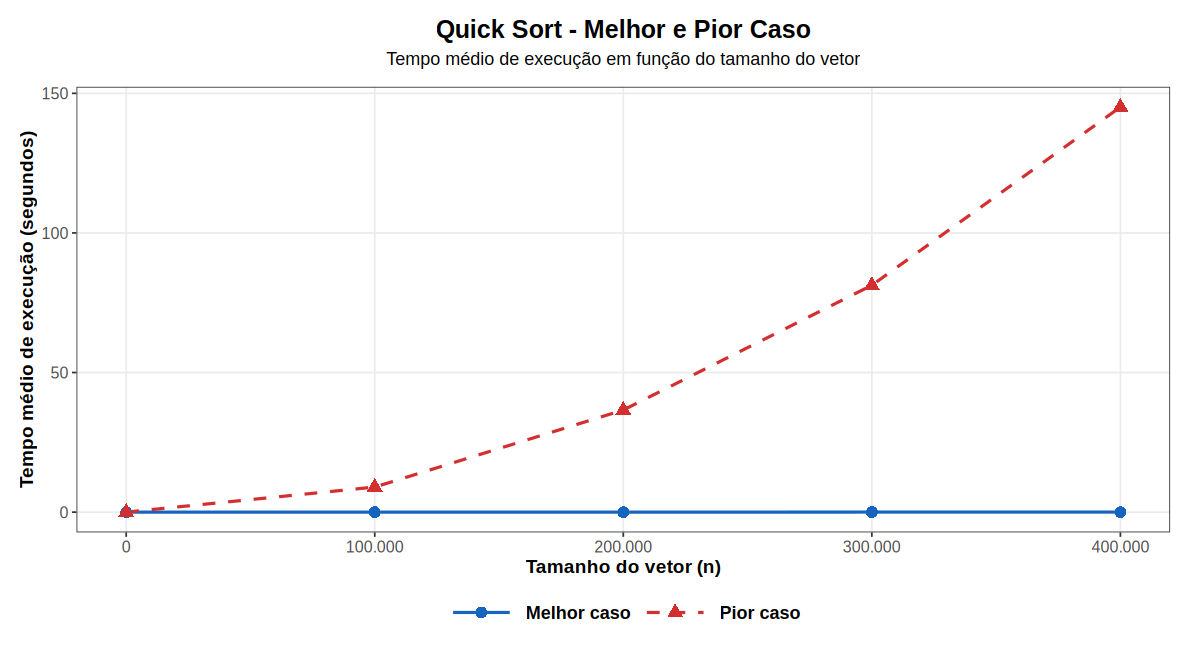

## **04 - Relatório**

O Quick Sort apresentou grande diferença entre o melhor e o pior caso. No melhor caso, o tempo cresceu lentamente, seguindo o comportamento esperado de O(n log n). No pior caso, o crescimento foi muito maior, aproximando-se de O(n²), devido às partições desbalanceadas.

Como limitação, os testes foram realizados somente até 400.000 elementos, e não até 500.000. O notebook utilizado para os testes é compartilhado com minha irmã, então optei por respeitar os horários de uso de cada uma. Como o pior caso possui comportamento O(n²), o teste com 500.000 elementos levaria um tempo consideravelmente maior. Por esse motivo, preferi manter os testes até 400.000 elementos, garantindo a execução completa e segura dentro do tempo disponível.

# **QUESTÃO 05 - Merge sort**

01 - Casos de testes

02 - Implementação

03 - Gráficos

04 - Relatório

# **QUESTÃO 06 - Comparação**

01 - Gráficos

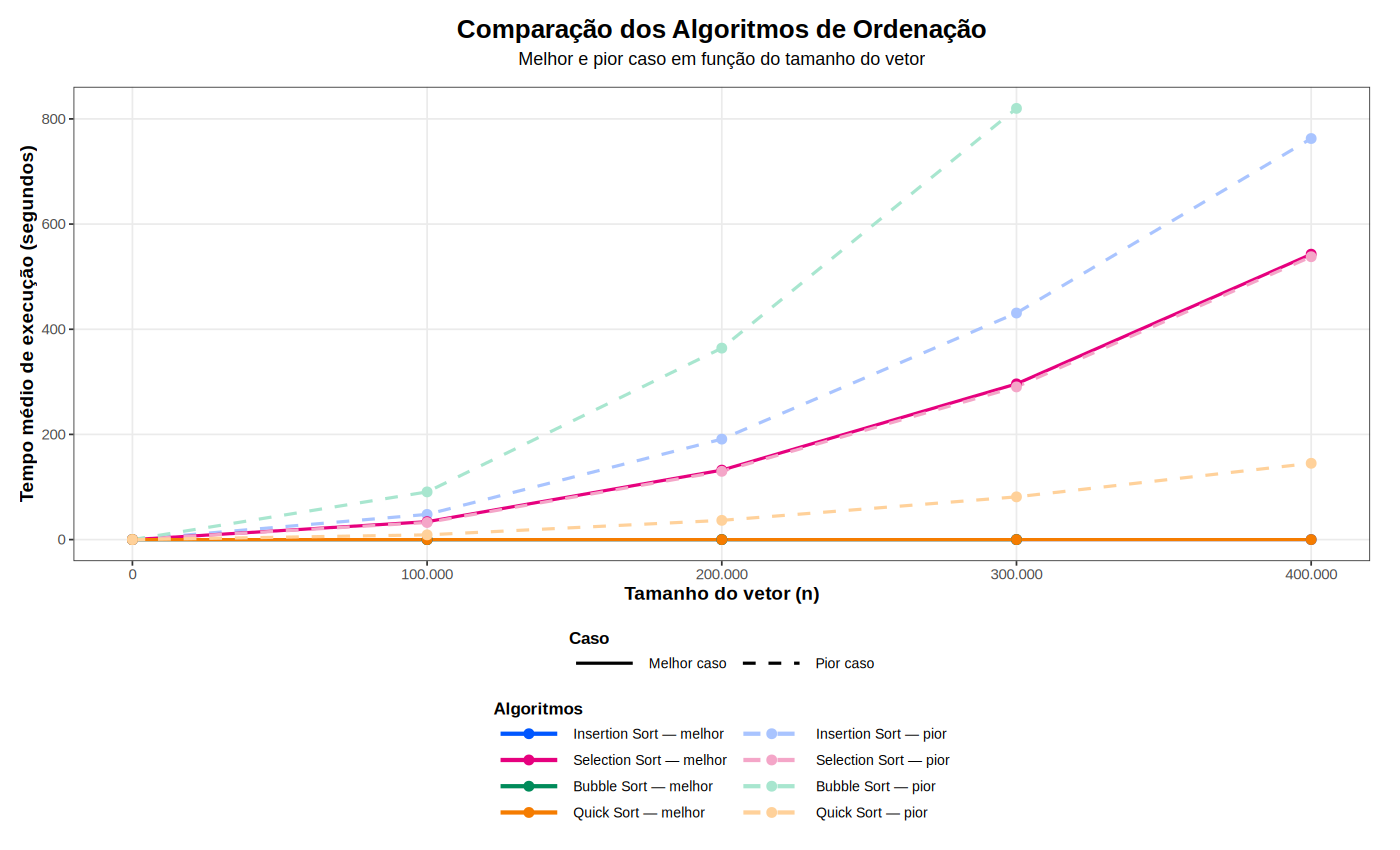

In [33]:
%%R -w 1400 -h 850

library(ggplot2)

#ler arquivos
q1 <- read.csv("questao01.csv")
q2 <- read.csv("questao02.csv")
q3 <- read.csv("questao03.csv")
q4 <- read.csv("questao04.csv")

#insertion sort
insertion_melhor <- data.frame(
  Tamanho = q1$Tamanho,
  Tempo_s = q1$MelhorCaso_ns / 1000000000,
  Algoritmo = "Insertion Sort",
  Caso = "Melhor caso"
)

insertion_pior <- data.frame(
  Tamanho = q1$Tamanho,
  Tempo_s = q1$PiorCaso_ns / 1000000000,
  Algoritmo = "Insertion Sort",
  Caso = "Pior caso"
)

#selection sort
selection_melhor <- data.frame(
  Tamanho = q2$Tamanho,
  Tempo_s = q2$MelhorCaso_ns / 1000000000,
  Algoritmo = "Selection Sort",
  Caso = "Melhor caso"
)

selection_pior <- data.frame(
  Tamanho = q2$Tamanho,
  Tempo_s = q2$PiorCaso_ns / 1000000000,
  Algoritmo = "Selection Sort",
  Caso = "Pior caso"
)

#bubble sort
bubble_melhor <- data.frame(
  Tamanho = q3$Tamanho,
  Tempo_s = q3$MelhorCaso_ns / 1000000000,
  Algoritmo = "Bubble Sort",
  Caso = "Melhor caso"
)

bubble_pior <- data.frame(
  Tamanho = q3$Tamanho,
  Tempo_s = q3$PiorCaso_ns / 1000000000,
  Algoritmo = "Bubble Sort",
  Caso = "Pior caso"
)

#quick sort
quick_melhor <- data.frame(
  Tamanho = q4$Tamanho,
  Tempo_s = q4$MelhorCaso_ns / 1000000000,
  Algoritmo = "Quick Sort",
  Caso = "Melhor caso"
)

quick_pior <- data.frame(
  Tamanho = q4$Tamanho,
  Tempo_s = q4$PiorCaso_ns / 1000000000,
  Algoritmo = "Quick Sort",
  Caso = "Pior caso"
)

#juntar dados
dados_grafico <- rbind(
  insertion_melhor,
  insertion_pior,
  selection_melhor,
  selection_pior,
  bubble_melhor,
  bubble_pior,
  quick_melhor,
  quick_pior
)

#usar somente ate 400000
dados_grafico <- subset(dados_grafico, Tamanho <= 400000)

#identificar cada linha
dados_grafico$Serie <- paste(
  dados_grafico$Algoritmo,
  dados_grafico$Caso,
  sep = " - "
)

#organizar ordem da legenda
dados_grafico$Serie <- factor(
  dados_grafico$Serie,
  levels = c(
    "Insertion Sort - Melhor caso",
    "Insertion Sort - Pior caso",
    "Selection Sort - Melhor caso",
    "Selection Sort - Pior caso",
    "Bubble Sort - Melhor caso",
    "Bubble Sort - Pior caso",
    "Quick Sort - Melhor caso",
    "Quick Sort - Pior caso"
  )
)

#cores
cores <- c(
  "Insertion Sort - Melhor caso" = "#0057FF",
  "Insertion Sort - Pior caso" = "#A9C4FF",

  "Selection Sort - Melhor caso" = "#E6007E",
  "Selection Sort - Pior caso" = "#F4A6C8",

  "Bubble Sort - Melhor caso" = "#008B5A",
  "Bubble Sort - Pior caso" = "#A8E6CF",

  "Quick Sort - Melhor caso" = "#F57C00",
  "Quick Sort - Pior caso" = "#FFD19A"
)

#nomes da legenda
nomes <- c(
  "Insertion Sort - Melhor caso" = "Insertion Sort — melhor",
  "Insertion Sort - Pior caso" = "Insertion Sort — pior",

  "Selection Sort - Melhor caso" = "Selection Sort — melhor",
  "Selection Sort - Pior caso" = "Selection Sort — pior",

  "Bubble Sort - Melhor caso" = "Bubble Sort — melhor",
  "Bubble Sort - Pior caso" = "Bubble Sort — pior",

  "Quick Sort - Melhor caso" = "Quick Sort — melhor",
  "Quick Sort - Pior caso" = "Quick Sort — pior"
)

#criar grafico
grafico <- ggplot(
  dados_grafico,
  aes(
    x = Tamanho,
    y = Tempo_s,
    color = Serie,
    group = Serie,
    linetype = Caso
  )
) +

  geom_line(
    linewidth = 1.5,
    na.rm = TRUE
  ) +

  geom_point(
    size = 4,
    na.rm = TRUE
  ) +

  scale_color_manual(
    values = cores,
    labels = nomes,
    name = "Algoritmos"
  ) +

  scale_linetype_manual(
    values = c(
      "Melhor caso" = "solid",
      "Pior caso" = "dashed"
    ),
    name = "Caso"
  ) +

  scale_x_continuous(
    limits = c(0, 400000),
    breaks = seq(0, 400000, by = 100000),
    labels = function(x) format(
      x,
      big.mark = ".",
      decimal.mark = ",",
      scientific = FALSE,
      trim = TRUE
    )
  ) +

  labs(
    title = "Comparação dos Algoritmos de Ordenação",
    subtitle = "Melhor e pior caso em função do tamanho do vetor",
    x = "Tamanho do vetor (n)",
    y = "Tempo médio de execução (segundos)"
  ) +

  guides(

    linetype = guide_legend(
      order = 1,
      title.position = "top",
      nrow = 1,
      override.aes = list(
        color = "black",
        linewidth = 1.5
      )
    ),

    color = guide_legend(
      order = 2,
      title.position = "top",
      ncol = 2,
      byrow = TRUE,
      override.aes = list(
        linewidth = 2,
        linetype = c(
          "solid", "dashed",
          "solid", "dashed",
          "solid", "dashed",
          "solid", "dashed"
        )
      )
    )
  ) +

  theme_bw(base_size = 18) +

  theme(
    plot.title = element_text(
      size = 26,
      face = "bold",
      hjust = 0.5
    ),

    plot.subtitle = element_text(
      size = 18,
      hjust = 0.5,
      margin = margin(b = 18)
    ),

    axis.title = element_text(
      size = 19,
      face = "bold"
    ),

    axis.text = element_text(
      size = 15
    ),

    legend.position = "bottom",

    legend.box = "vertical",

    legend.title = element_text(
      size = 17,
      face = "bold"
    ),

    legend.text = element_text(
      size = 14
    ),

    legend.key.width = unit(2.5, "cm"),

    legend.spacing.y = unit(0.4, "cm"),

    panel.grid.minor = element_blank(),

    plot.margin = margin(
      20,
      30,
      20,
      20
    )
  )

#mostrar grafico
print(grafico)

#salvar grafico
ggsave(
  "comparacao_algoritmos.png",
  plot = grafico,
  width = 14,
  height = 8.5,
  units = "in",
  dpi = 300
)

grafico com evidencia de diferença

Biblioteca R para evitar sobreposição de dados

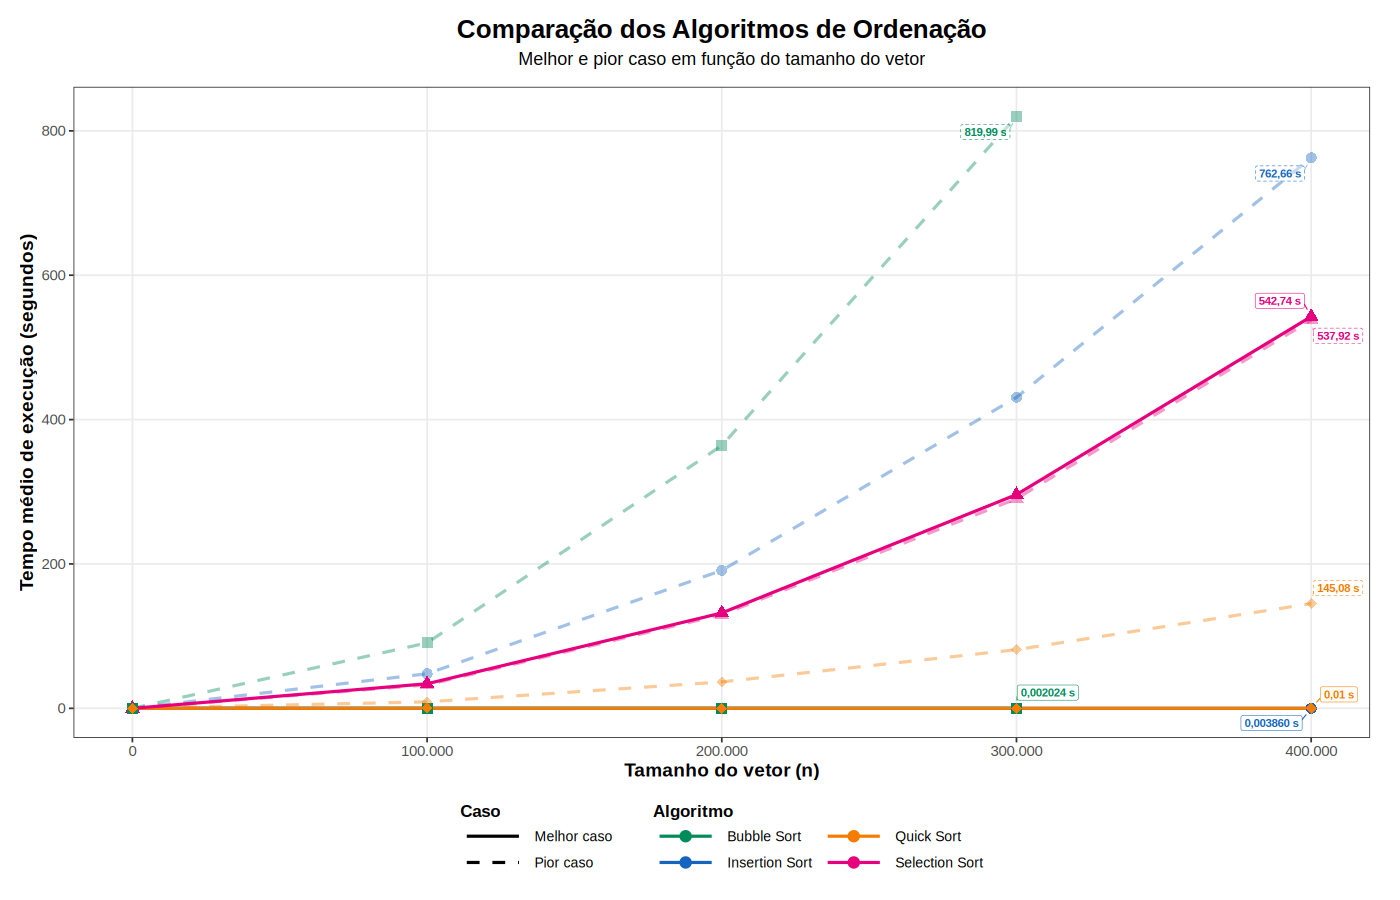

In [41]:
%%R -w 1400 -h 900

library(ggplot2)

#instalar ggrepel
if (!requireNamespace("ggrepel", quietly = TRUE)) {
  install.packages("ggrepel", repos = "https://cloud.r-project.org")
}

library(ggrepel)

#ler arquivos
q1 <- read.csv("questao01.csv")
q2 <- read.csv("questao02.csv")
q3 <- read.csv("questao03.csv")
q4 <- read.csv("questao04.csv")

#insertion sort
insertion_melhor <- data.frame(
  Tamanho = q1$Tamanho,
  Tempo_s = q1$MelhorCaso_ns / 1000000000,
  Algoritmo = "Insertion Sort",
  Caso = "Melhor caso"
)

insertion_pior <- data.frame(
  Tamanho = q1$Tamanho,
  Tempo_s = q1$PiorCaso_ns / 1000000000,
  Algoritmo = "Insertion Sort",
  Caso = "Pior caso"
)

#selection sort
selection_melhor <- data.frame(
  Tamanho = q2$Tamanho,
  Tempo_s = q2$MelhorCaso_ns / 1000000000,
  Algoritmo = "Selection Sort",
  Caso = "Melhor caso"
)

selection_pior <- data.frame(
  Tamanho = q2$Tamanho,
  Tempo_s = q2$PiorCaso_ns / 1000000000,
  Algoritmo = "Selection Sort",
  Caso = "Pior caso"
)

#bubble sort
bubble_melhor <- data.frame(
  Tamanho = q3$Tamanho,
  Tempo_s = q3$MelhorCaso_ns / 1000000000,
  Algoritmo = "Bubble Sort",
  Caso = "Melhor caso"
)

bubble_pior <- data.frame(
  Tamanho = q3$Tamanho,
  Tempo_s = q3$PiorCaso_ns / 1000000000,
  Algoritmo = "Bubble Sort",
  Caso = "Pior caso"
)

#quick sort
quick_melhor <- data.frame(
  Tamanho = q4$Tamanho,
  Tempo_s = q4$MelhorCaso_ns / 1000000000,
  Algoritmo = "Quick Sort",
  Caso = "Melhor caso"
)

quick_pior <- data.frame(
  Tamanho = q4$Tamanho,
  Tempo_s = q4$PiorCaso_ns / 1000000000,
  Algoritmo = "Quick Sort",
  Caso = "Pior caso"
)

#juntar dados
dados_grafico <- rbind(
  insertion_melhor,
  insertion_pior,
  selection_melhor,
  selection_pior,
  bubble_melhor,
  bubble_pior,
  quick_melhor,
  quick_pior
)

#usar somente ate 400000
dados_grafico <- subset(
  dados_grafico,
  Tamanho <= 400000
)

#remover valores ausentes
dados_grafico <- dados_grafico[
  !is.na(dados_grafico$Tempo_s),
]

#identificar cada serie
dados_grafico$Serie <- paste(
  dados_grafico$Algoritmo,
  dados_grafico$Caso,
  sep = " - "
)

#cores dos algoritmos
cores_algoritmos <- c(
  "Insertion Sort" = "#1565C0",
  "Selection Sort" = "#E6007E",
  "Bubble Sort" = "#008B5A",
  "Quick Sort" = "#F57C00"
)

#pegar ultimo resultado de cada serie
dados_rotulos <- do.call(
  rbind,
  lapply(
    split(dados_grafico, dados_grafico$Serie),
    function(x) {
      x[which.max(x$Tamanho), ]
    }
  )
)

#formatar tempos
dados_rotulos$Rotulo <- ifelse(
  dados_rotulos$Tempo_s < 0.01,
  paste0(
    format(
      round(dados_rotulos$Tempo_s, 6),
      decimal.mark = ",",
      scientific = FALSE,
      trim = TRUE
    ),
    " s"
  ),
  paste0(
    format(
      round(dados_rotulos$Tempo_s, 2),
      decimal.mark = ",",
      big.mark = ".",
      scientific = FALSE,
      trim = TRUE
    ),
    " s"
  )
)

#criar grafico
grafico <- ggplot(
  dados_grafico,
  aes(
    x = Tamanho,
    y = Tempo_s,
    group = Serie,
    color = Algoritmo,
    linetype = Caso,
    alpha = Caso
  )
) +

  geom_line(
    linewidth = 1.5
  ) +

  geom_point(
    aes(shape = Algoritmo),
    size = 4.5,
    stroke = 1
  ) +

  #mostrar tempo no ultimo ponto
  geom_label_repel(
    data = dados_rotulos,
    aes(
      x = Tamanho,
      y = Tempo_s,
      label = Rotulo,
      color = Algoritmo
    ),
    size = 4,
    fontface = "bold",
    fill = "white",
    label.size = 0.25,
    box.padding = 0.5,
    point.padding = 0.5,
    min.segment.length = 0,
    max.overlaps = Inf,
    show.legend = FALSE,
    seed = 10
  ) +

  #cores
  scale_color_manual(
    values = cores_algoritmos,
    name = "Algoritmo"
  ) +

  #melhor e pior caso
  scale_linetype_manual(
    values = c(
      "Melhor caso" = "solid",
      "Pior caso" = "dashed"
    ),
    name = "Caso"
  ) +

  #pior caso mais claro
  scale_alpha_manual(
    values = c(
      "Melhor caso" = 1,
      "Pior caso" = 0.40
    ),
    guide = "none"
  ) +

  #simbolos
  scale_shape_manual(
    values = c(
      "Insertion Sort" = 16,
      "Selection Sort" = 17,
      "Bubble Sort" = 15,
      "Quick Sort" = 18
    ),
    name = "Algoritmo"
  ) +

  #eixo x
  scale_x_continuous(
    limits = c(0, 400000),
    breaks = seq(
      0,
      400000,
      by = 100000
    ),
    labels = function(x) format(
      x,
      big.mark = ".",
      decimal.mark = ",",
      scientific = FALSE,
      trim = TRUE
    )
  ) +

  labs(
    title = "Comparação dos Algoritmos de Ordenação",
    subtitle = "Melhor e pior caso em função do tamanho do vetor",
    x = "Tamanho do vetor (n)",
    y = "Tempo médio de execução (segundos)"
  ) +

  #organizar legendas
  guides(

    linetype = guide_legend(
      order = 1,
      title.position = "top",
      ncol = 1,
      override.aes = list(
        color = "black",
        alpha = 1,
        linewidth = 1.5
      )
    ),

    color = guide_legend(
      order = 2,
      title.position = "top",
      ncol = 2,
      override.aes = list(
        alpha = 1,
        linetype = "solid",
        linewidth = 1.5
      )
    ),

    shape = "none"
  ) +

  theme_bw(
    base_size = 18
  ) +

  theme(

    plot.title = element_text(
      size = 26,
      face = "bold",
      hjust = 0.5
    ),

    plot.subtitle = element_text(
      size = 18,
      hjust = 0.5,
      margin = margin(b = 18)
    ),

    axis.title = element_text(
      size = 19,
      face = "bold"
    ),

    axis.text = element_text(
      size = 15
    ),

    #legendas embaixo
    legend.position = "bottom",

    #caso de um lado e algoritmo do outro
    legend.box = "horizontal",

    legend.box.just = "center",

    legend.title = element_text(
      size = 17,
      face = "bold"
    ),

    legend.text = element_text(
      size = 14
    ),

    legend.key.width = unit(
      2.3,
      "cm"
    ),

    legend.spacing.x = unit(
      0.8,
      "cm"
    ),

    legend.box.spacing = unit(
      0.5,
      "cm"
    ),

    panel.grid.minor = element_blank(),

    plot.margin = margin(
      20,
      30,
      20,
      20
    )
  )

#mostrar grafico
print(grafico)

#salvar grafico
ggsave(
  "comparacao_algoritmos.png",
  plot = grafico,
  width = 14,
  height = 9,
  units = "in",
  dpi = 300
)

GRAFICO DE COMPARAÇÃO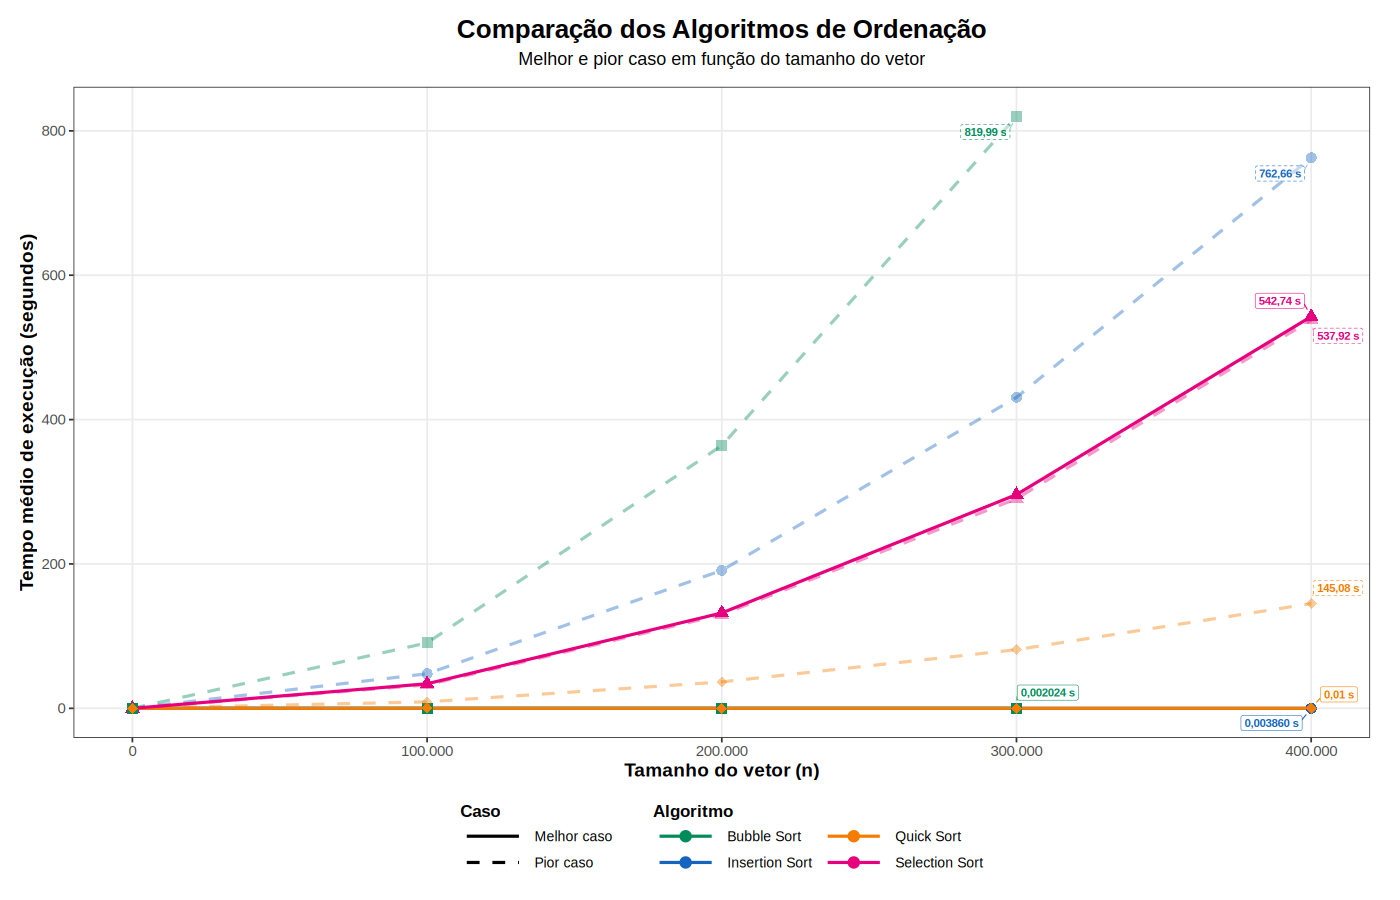

02 - Relatório